In [91]:
%load_ext kedro.ipython

The kedro.ipython extension is already loaded. To reload it, use:
  %reload_ext kedro.ipython


In [92]:
import pandas as pd

exp_data = catalog.load("experiment_data")
exp_data.head()

[06/24/26 18:18:48] INFO     Loading data from experiment_data (ExcelDataset)...               ]8;id=112972;file://c:\Users\defaultuser100000\github_repos\predictive_maintenance\python_3116_venv\Lib\site-packages\kedro\io\data_catalog.py\data_catalog.py]8;;\:]8;id=62123;file://c:\Users\defaultuser100000\github_repos\predictive_maintenance\python_3116_venv\Lib\site-packages\kedro\io\data_catalog.py#1053\1053]8;;\

,id,T_melt,t_holdingpressure,Reskühlzeit_t_cooling,p_holdingpressure,V_injection,T_cooling,Zeit,Quality
0,1,210,0.1,2,200,6,30,12.18,0.0
1,2,210,0.1,2,200,12,30,11.11,0.0
2,3,210,0.1,2,200,20,30,10.71,0.0
3,4,210,0.1,2,350,6,30,12.30,0.0
4,5,210,0.1,2,350,12,30,11.27,0.0


In [93]:
exp_data.dtypes


id                         int64
T_melt                     int64
t_holdingpressure        float64
Reskühlzeit_t_cooling      int64
p_holdingpressure          int64
V_injection                int64
T_cooling                  int64
Zeit                     float64
Quality                  float64
dtype: object

In [94]:
exp_data.shape

(1121, 9)

In [95]:
partitioned_chart_data = catalog.load("chart_data")

[06/24/26 18:18:49] INFO     Loading data from chart_data (PartitionedDataset)...              ]8;id=448610;file://c:\Users\defaultuser100000\github_repos\predictive_maintenance\python_3116_venv\Lib\site-packages\kedro\io\data_catalog.py\data_catalog.py]8;;\:]8;id=136435;file://c:\Users\defaultuser100000\github_repos\predictive_maintenance\python_3116_venv\Lib\site-packages\kedro\io\data_catalog.py#1053\1053]8;;\

## Preprocessing

In [96]:
import re
from collections import defaultdict
from functools import reduce
from typing import Dict, Any, List

In [97]:
# Groups filenames using regex
def _group_partitions(partition_ids: List[str]) -> Dict[str, List[str]]:
    groups = defaultdict(list)
    pattern = re.compile(r"(.*_measurement_)\d+(_.*)")

    for p_id in partition_ids:
        match = pattern.match(p_id)
        if match:
            key = match.group(1) + match.group(2)
            groups[key].append(p_id)
    return groups


# Loads, cleans, and merges a single group of files
def _load_and_merge_group(partition_ids: List[str]) -> pd.DataFrame:
    df_list = []
    # Relative path ensures this works on ANY computer, not just yours!
    base_path = "data/01_raw/chart_data"

    for p_id in sorted(partition_ids):
        try:
            df = pd.read_csv(
                f"{base_path}/{p_id}.txt",
                sep=";",
                skiprows=11,
                encoding="utf-16",
                engine="python",
            )
            if df.empty:
                continue

            # Clean trailing columns and whitespaces
            df = df.iloc[:, :-1]
            df.columns = df.columns.str.strip()
            df_list.append(df)
        except Exception:
            continue

    if not df_list:
        return pd.DataFrame()

    # Outer merge all dataframes within this specific group
    return reduce(
        lambda left, right: pd.merge(left, right, on="time", how="outer"), df_list
    )


# The main orchestrator for processing chart_data
def preprocess_and_merge_charts(partitioned_input: Dict[str, Any]) -> pd.DataFrame:
    """Processes, cleans, outer-merges, and concatenates all chart data files."""

    # Step 1: Group the partitions
    groups = _group_partitions(list(partitioned_input.keys()))

    # Step 2: Merge data within each group
    merged_dfs = []
    for key, partition_ids in groups.items():
        df_merge = _load_and_merge_group(partition_ids)
        if not df_merge.empty:
            merged_dfs.append(df_merge)

    if not merged_dfs:
        return pd.DataFrame()

    # Step 3: Add incremental experiment IDs
    all_dfs = []
    for idx, df in enumerate(merged_dfs):
        cleaned_df = df[df["time"] != "-start data-"].dropna(subset=["time"])
        temp_df = cleaned_df.copy()
        temp_df["id"] = idx + 1
        all_dfs.append(temp_df)

    # Step 4: Combine, format types, and sort
    chart_data = pd.concat(all_dfs, ignore_index=True)
    chart_data = chart_data.apply(pd.to_numeric, errors="coerce")
    chart_data = chart_data.sort_values(by=["id", "time"]).reset_index(drop=True)

    return chart_data


# Get only relevant data with labels from experiment_data
def preprocess_experiment_data(df: pd.DataFrame) -> pd.DataFrame:
    """Clean the raw injection molding experiment data"""
    return df.dropna(subset=["Quality"])

In [98]:
exp_data = preprocess_experiment_data(exp_data)
exp_data.head()

,id,T_melt,t_holdingpressure,Reskühlzeit_t_cooling,p_holdingpressure,V_injection,T_cooling,Zeit,Quality
0,1,210,0.1,2,200,6,30,12.18,0.0
1,2,210,0.1,2,200,12,30,11.11,0.0
2,3,210,0.1,2,200,20,30,10.71,0.0
3,4,210,0.1,2,350,6,30,12.30,0.0
4,5,210,0.1,2,350,12,30,11.27,0.0


In [99]:
import os

# If you are inside the notebooks folder, hop out to the root project folder
if os.getcwd().endswith("notebooks"):
    os.chdir("..")

print(f"New Working Directory: {os.getcwd()}")

chart_data = preprocess_and_merge_charts(partitioned_chart_data)
chart_data.head()

New Working Directory: c:\Users\defaultuser100000\github_repos\digital_twin\digital-twin\digital-twin


,time,"Einspritzdruck, Ist","Schneckenvolumen, Ist","Auswerferweg, Ist","Einspritzstrom, Ist","Werkzeuggeschwindigkeit, Ist","Auswerfergeschwindigkeit, Ist","Werkzeugkraft, Ist","Werkzeugweg, Ist","Druckmesssystem 3, Ist","Temperaturmesssystem 5, Ist",id
0,0.00,-0.70,18.50,-0.02,0.00,-0.95,0.00,119.38,-0.02,0.0,31.1,1
1,0.05,22.98,18.34,-0.04,5.41,0.00,0.31,119.05,-0.02,0.0,31.2,1
2,0.10,25.27,18.04,-0.04,5.95,0.00,0.31,118.83,-0.02,0.0,31.1,1
3,0.15,26.96,17.75,-0.04,5.95,0.95,0.00,118.61,-0.02,0.0,31.1,1
4,0.20,38.99,17.45,-0.01,5.95,0.00,0.00,118.50,-0.02,0.0,31.1,1


In [13]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler, LabelEncoder

def plot_chart_data(chart_df: pd.DataFrame):

    # Initialize a new figure with specific dimensions
    plt.figure(figsize=(10,6))

    # Get a list of all column names except for "time" to identify the sensor parameters
    params = chart_df.columns.drop(["time", "id"])

    # scale data only for plot
    # scaler = MinMaxScaler()
    # scaled_chart_data = pd.DataFrame(scaler.fit_transform(chart_df[params]), columns=params)
    # scaled_chart_data['time'] = chart_df['time']
    # scaled_chart_data['id'] = chart_df['id']
    scaled_chart_data = chart_data

    # Iterate through the parameter list to plot each sensor's data
    for idx, param in enumerate(params):
        # Limit the plot to only the first 4 parameters to prevent visual clutter
        if idx == 5 or idx == 7:
            for id in range(33, 50):
                # Create a line plot for the current parameter against the time axis
                sns.lineplot(data=scaled_chart_data[scaled_chart_data['id'] == id], x='time', y=param, label=param)

    # # Set the descriptive title and axis labels for the chart
    # plt.title("Sensor Parameters")
    # plt.xlabel("time")
    # plt.ylabel("Param value")

    # # Place the legend in the bottom right corner to avoid overlapping with data lines
    # plt.legend(loc="lower right")

            # Render the final plot
            plt.show()

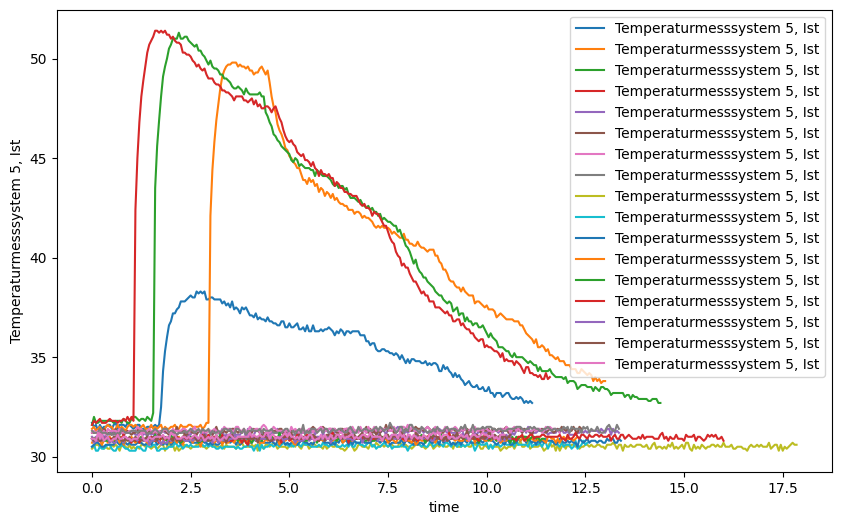

In [14]:
plot_chart_data(chart_data)